# Simulationen zu den Modellen 2 bis 4

In diesem Notebook werden die Trefferzeiten $T$ für drei Modelle simuliert und mit den exakten Wahrscheinlichkeiten verglichen.

Die Simulation liefert zunächst Daten. Aus diesen Daten werden relative Häufigkeiten $H(T=n)$ berechnet. Die exakten Wahrscheinlichkeiten $P(T=n)$ werden nur zum Vergleich in die Grafik eingezeichnet.


## Globale Einstellungen

Die Anzahl der Simulationen ist $N$. Durch den festen Startwert `SEED` sind die Ergebnisse reproduzierbar. Das bedeutet: Beim erneuten Ausführen entstehen dieselben Zufallsdaten und damit dieselben Abbildungen.


In [1]:
import math
from statistics import NormalDist

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Globale Einstellungen
# ------------------------------------------------------------
N = 10_000
SEED = 20260520

BAR_WIDTH = 0.15
KONFIDENZNIVEAU = 0.95

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.grid": False,
    "grid.color": "0.85",
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
})


## Wilson-Konfidenzintervalle

Für jeden festen Wert $n$ wird gezählt, wie oft in der Simulation $T=n$ gilt. Ist diese Anzahl $k_n$, so ist

$$
\hat p_n=\frac{k_n}{N}
$$

die simulierte relative Häufigkeit. Sie dient als Schätzwert für die unbekannte Wahrscheinlichkeit

$$
p_n=P(T=n).
$$

Die Konfidenzintervalle werden aus den simulierten Häufigkeiten berechnet. Die exakten Wahrscheinlichkeiten werden dafür nicht benutzt.

Gerade bei kleinen Wahrscheinlichkeiten ist das Wilson-Intervall günstiger als die einfache Normalapproximation. Es liefert auch dann sinnvolle Intervalle, wenn ein bestimmter Wert $n$ in der Simulation gar nicht auftritt.

Da $T$ nur ganzzahlige Werte annimmt, werden die punktweisen Wilson-Konfidenzintervalle als einzelne senkrechte Intervalle dargestellt.

Die Balken zeigen die simulierten relativen Häufigkeiten $\hat p_n$. Die schwarzen Punkte markieren die exakten Wahrscheinlichkeiten $P(T=n)$.

In [2]:
# ------------------------------------------------------------
# Wilson-Konfidenzintervalle
# ------------------------------------------------------------
def wilson_intervall(k, n, konfidenzniveau=0.95):
    """
    Punktweise Wilson-Konfidenzintervalle für eine unbekannte
    Wahrscheinlichkeit p.

    k: Anzahl der Treffer; darf auch ein NumPy-Array sein
    n: Anzahl der Simulationen
    konfidenzniveau: z. B. 0.95 für ein 95%-Konfidenzintervall
    """
    k = np.asarray(k, dtype=float)
    p_hat = k / n

    alpha = 1 - konfidenzniveau
    z = NormalDist().inv_cdf(1 - alpha / 2)

    faktor = 1 + z**2 / n
    mitte = (p_hat + z**2 / (2 * n)) / faktor
    halbe_breite = (
        z
        * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
        / faktor
    )

    lower = np.maximum(0, mitte - halbe_breite)
    upper = np.minimum(1, mitte + halbe_breite)

    return lower, upper


## Simulation der Modelle

Jede Simulationsfunktion erzeugt genau eine Trefferzeit $T$. Später wird diese Funktion $N$-mal aufgerufen.

- Bei Modell 2 (Sammelmodell) wird ein passender Buchstabe nach einem Treffer entfernt.
- Bei Modell 3 (Strommodell) wird ein fortlaufender Strom unabhängiger Buchstaben betrachtet. Entscheidend ist hier nicht das Sammeln der  Buchstaben,sondern das erste Auftreten der zusammenhängenden Folge $OMA$.
- Bei Modell 4 (Zurücklegen, s. GitHub) wird nach jedem Zug wieder aus allen drei Buchstaben gezogen. 

In [3]:
# ------------------------------------------------------------
# Simulationen
# ------------------------------------------------------------
def simulation_2(rng):
    ziel = ["O", "M", "A"]
    urne = ["A", "M", "O"]
    zustand = 0
    t = 0

    while zustand < 3:
        buchstabe = rng.choice(urne)
        t += 1

        if buchstabe == ziel[zustand]:
            urne.remove(buchstabe)
            zustand += 1

    return t


def simulation_strom(rng):
    buchstaben = ["A", "M", "O"]

    # Zustände:
    # 0: Startzustand
    # 1: O wurde zuletzt passend erreicht
    # 2: OM wurde zuletzt passend erreicht
    # 3: OMA erreicht

    zustand = 0
    t = 0

    while zustand < 3:
        buchstabe = rng.choice(buchstaben)
        t += 1

        if zustand == 0:
            if buchstabe == "O":
                zustand = 1

        elif zustand == 1:
            if buchstabe == "O":
                zustand = 1
            elif buchstabe == "M":
                zustand = 2
            else:
                zustand = 0

        elif zustand == 2:
            if buchstabe == "A":
                zustand = 3
            elif buchstabe == "O":
                zustand = 1
            else:
                zustand = 0

    return t

def simulation_4(rng):
    ziel = ["O", "M", "A"]
    zustand = 0
    t = 0

    while zustand < 3:
        buchstabe = rng.choice(["A", "M", "O"])
        t += 1

        if buchstabe == ziel[zustand]:
            zustand += 1

    return t

## Exakte Wahrscheinlichkeiten

Für Modell 2 und Modell 4 werden die exakten Wahrscheinlichkeiten durch Formeln berechnet. Beim Strommodell (Modell 3) wird eine Übergangsmatrix verwendet.

Im Programm ist $Q$ die transiente Übergangsmatrix. Der absorbierende Zielzustand $OMA$ ist darin nicht mehr enthalten. Der Vektor `absorb` enthält die Wahrscheinlichkeiten, im nächsten Schritt in den Zielzustand zu gelangen.

Mit dem Startvektor $v_0=(1,0,0)$ gilt im Programm sinngemäß

$$
P(T=t)=v_{t-1}a,\qquad v_t=v_{t-1}Q.
$$

Hier wird also mit Zeilenvektoren gerechnet. Das ist programmiertechnisch kompakt; im Unterricht kann man dieselbe Idee natürlich auch mit Spaltenvektoren darstellen.


In [4]:
# ------------------------------------------------------------
# Exakte Wahrscheinlichkeiten
# ------------------------------------------------------------
def pmf_2(n):
    if n < 3:
        return 0.0

    return (2 / 3) ** (n - 2) - (1 / 2) ** (n - 2)


def pmf_strom_array(n_values):
    # Für die exakte Verteilung wird die transiente Übergangsmatrix Q
    # verwendet. Das ist die Übergangsmatrix ohne den absorbierenden
    # Zielzustand OMA. Der Vektor absorb enthält die Übergangswahrscheinlich-
    # keiten aus den transienten Zuständen in den Zielzustand.
    Q = np.array([
        [2 / 3, 1 / 3, 0],
        [1 / 3, 1 / 3, 1 / 3],
        [1 / 3, 1 / 3, 0]
    ], dtype=float)

    absorb = np.array([0, 0, 1 / 3], dtype=float)

    max_n = int(np.max(n_values))
    state = np.array([1, 0, 0], dtype=float)

    probs = {}

    for t in range(1, max_n + 1):
        probs[t] = float(state @ absorb)
        state = state @ Q

    return np.array([probs.get(int(n), 0.0) for n in n_values])


def pmf_4(n):
    if n < 3:
        return 0.0

    return math.comb(n - 1, 2) * (1 / 3) ** 3 * (2 / 3) ** (n - 3)

## Modelldaten

Die Liste `modelle` bündelt für jedes Modell die Simulationsfunktion, die exakte Verteilung, die theoretischen Kenngrößen und den Startwert für den Zufallsgenerator. Dadurch kann dieselbe Auswertungsfunktion für alle drei Modelle benutzt werden.


In [5]:
# ------------------------------------------------------------
# Modelldaten
# ------------------------------------------------------------
modelle = [
    {
        "name": "Modell 2: Passendes bleibt liegen",
        "dateiname": "oma_modell_2",
        "sim": simulation_2,
        "pmf": lambda ns: np.array([pmf_2(int(n)) for n in ns]),
        "E": 6,
        "V": 8,
        "seed": SEED + 1
    },
    {
        "name": " Modell 3: Strommodell",
        "dateiname": "oma_strommodell",
        "sim": simulation_strom,
        "pmf": pmf_strom_array,
        "E": 27,
        "V": 594,
        "seed": SEED + 2
    },
    {
        "name": "Modell 4: Zurücklegen nach Treffer",
        "dateiname": "oma_modell_4",
        "sim": simulation_4,
        "pmf": lambda ns: np.array([pmf_4(int(n)) for n in ns]),
        "E": 9,
        "V": 18,
        "seed": SEED + 3
    },
]


## Auswertung und Grafik

Für jedes Modell werden zunächst $N$ Trefferzeiten simuliert. Daraus entstehen die absoluten Häufigkeiten $k_n$ und die relativen Häufigkeiten

$$
H(T=n)=\frac{k_n}{N}.
$$

Das graue Intervallband zeigt punktweise Wilson-Konfidenzintervalle auf Grundlage der simulierten Werte. Die schwarzen Punkte zeigen die exakten Wahrscheinlichkeiten $P(T=n)$ und dienen nur als Vergleich.


In [6]:
# ------------------------------------------------------------
# Auswertung und Grafik für ein Modell
# ------------------------------------------------------------
def auswertung_und_grafik(modell):
    rng = np.random.default_rng(modell["seed"])

    daten = np.array([modell["sim"](rng) for _ in range(N)])

    # Darstellungsbereich:
    # Der lange Restschwanz wird nicht vollständig gezeigt.
    max_n = int(np.quantile(daten, 0.995))
    max_n = max(max_n, 12)

    n_values = np.arange(3, max_n + 1)

    counts = np.bincount(daten, minlength=max_n + 1)
    absolute_haeufigkeiten = counts[n_values]
    rel_freq = absolute_haeufigkeiten / N

    p_exact = modell["pmf"](n_values)

    # Punktweise 95%-Wilson-Konfidenzintervalle.
    # Sie werden aus den simulierten Häufigkeiten berechnet,
    # nicht aus den exakten Wahrscheinlichkeiten.
    lower, upper = wilson_intervall(
        absolute_haeufigkeiten,
        N,
        konfidenzniveau=KONFIDENZNIVEAU
    )

    # Kenngrößen
    mean_sim = np.mean(daten)
    var_sim = np.var(daten, ddof=1)

    print()
    print(modell["name"])
    print("-" * len(modell["name"]))
    print(f"N                         = {N}")
    print(f"seed                      = {modell['seed']}")
    print(f"E(T) Simulation            = {mean_sim:.4f}")
    print(f"E(T) exakt                 = {modell['E']}")
    print(f"V(T) Simulation            = {var_sim:.4f}")
    print(f"V(T) exakt                 = {modell['V']}")

    # Grafik
    fig, ax = plt.subplots()

    ax.bar(
        n_values,
        rel_freq,
        width=BAR_WIDTH,
        color="0.75",
        edgecolor="black",
        linewidth=0.5,
        # label="Simulation: relative Häufigkeit",
        zorder=2
    )

    # Wilson-Intervalle als einzelne senkrechte Intervalle
    yerr = np.vstack([
        np.maximum(0, rel_freq - lower),
        np.maximum(0, upper - rel_freq)
    ])

    ax.errorbar(
        n_values,
        rel_freq,
        yerr=yerr,
        fmt="none",
        ecolor="0.35",  #0.25
        elinewidth=1.8, # 0.8
        capsize=3.5, #2
        capthick=1.0,  # 0.8,
        zorder=3
    )

    ax.scatter(
        n_values,
        p_exact,
        s=10,   # 18
        color="black",
        # label="exakte Wahrscheinlichkeiten",
        zorder=3
    )

    text = (
        f"N = {N:,}\n"
        f"seed = {modell['seed']}\n"
        f"E(T): Sim. {mean_sim:.3f} | exakt {modell['E']}\n"
        f"V(T): Sim. {var_sim:.3f} | exakt {modell['V']}"
    )

   
    ax.set_xlabel("n")
    ax.set_ylabel(r"$P(T=n),\ H(T=n)$")

    ax.set_axisbelow(True)

    fig.tight_layout()

    fig.savefig(f"{modell['dateiname']}.png", bbox_inches="tight")
    fig.savefig(f"{modell['dateiname']}.pdf", bbox_inches="tight")

    plt.show()

    return {
        "Modell": modell["name"],
        "N": N,
        "seed": modell["seed"],
        "E_sim": mean_sim,
        "E_exakt": modell["E"],
        "V_sim": var_sim,
        "V_exakt": modell["V"]
    }


## Alle Modelle auswerten

Zum Schluss wird dieselbe Auswertung für alle Modelle durchgeführt. Die Grafiken werden als PDF-Dateien gespeichert.



Modell 2: Passendes bleibt liegen
---------------------------------
N                         = 10000
seed                      = 20260521
E(T) Simulation            = 6.0170
E(T) exakt                 = 6
V(T) Simulation            = 8.2059
V(T) exakt                 = 8


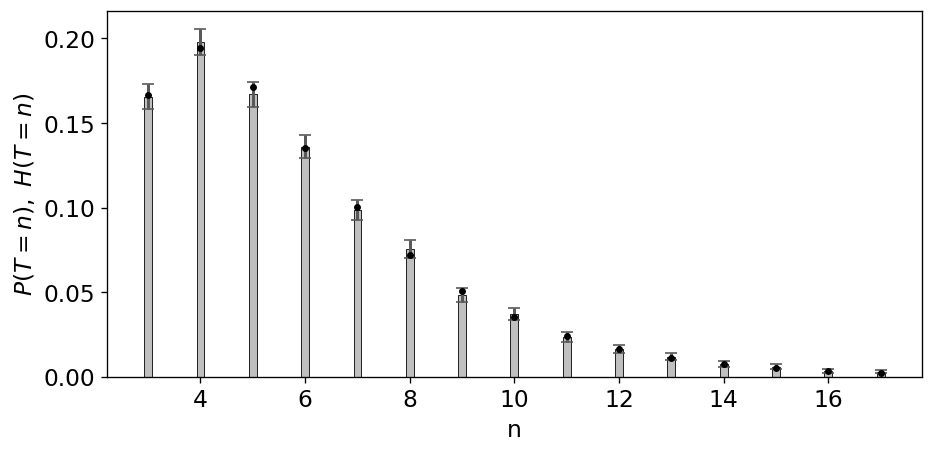


 Modell 3: Strommodell
----------------------
N                         = 10000
seed                      = 20260522
E(T) Simulation            = 27.0362
E(T) exakt                 = 27
V(T) Simulation            = 585.6865
V(T) exakt                 = 594


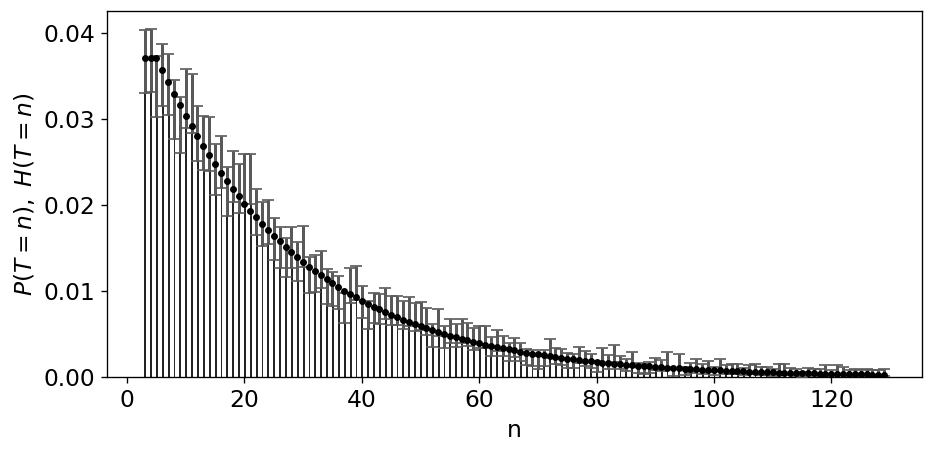


Modell 4: Zurücklegen nach Treffer
----------------------------------
N                         = 10000
seed                      = 20260523
E(T) Simulation            = 9.0005
E(T) exakt                 = 9
V(T) Simulation            = 17.4936
V(T) exakt                 = 18


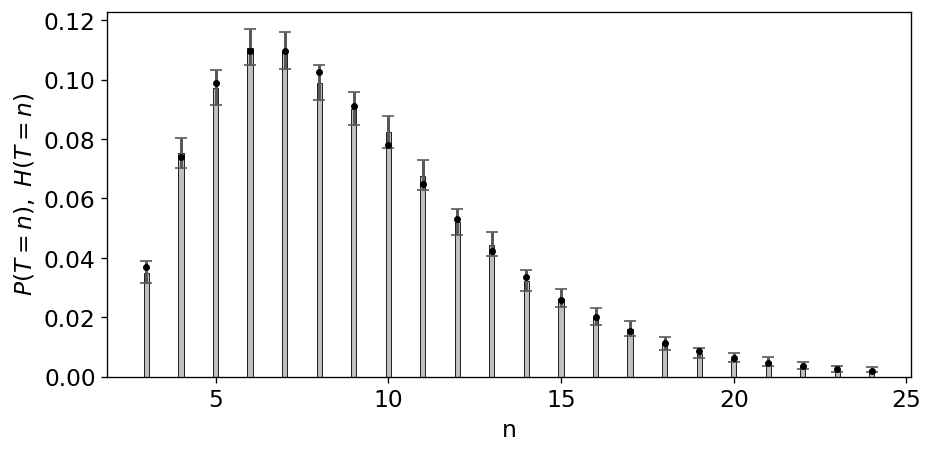

In [7]:
# ------------------------------------------------------------
# Alle Modelle auswerten
# ------------------------------------------------------------
ergebnisse = []

for modell in modelle:
    ergebnis = auswertung_und_grafik(modell)
    ergebnisse.append(ergebnis)
